* Draft: 2021-03-11 (Thu)
# Wine Dataset with XGBoost

## Execusitve Summary
### Data: Wine Dataset
* [Red Wine Quality](https://www.kaggle.com/uciml/red-wine-quality-cortez-et-al-2009), Kaggle Dataset
  * Simple and clean practice dataset for regression or classification modelling
  * The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine.
  * Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available
    * e.g. there is no data about grape types, wine brand, wine selling price, etc.
  * These datasets can be viewed as classification or regression tasks.
  * The classes are ordered and not balanced (e.g. there are much more normal wines than excellent or poor ones).
* [Wine Data Set](https://archive.ics.uci.edu/ml/datasets/wine), UCI Machine Learning Repository
  * Abstract: Using chemical analysis determine the origin of wines
  * Data Set Information:
    * These data are the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars. 
    * The analysis determined the quantities of 13 constituents found in each of the three types of wines.
  * The attributes are (dontated by Riccardo Leardi, riclea **'@'** anchem.unige.it )
  1. Alcohol
  2. Malic acid
  3. Ash
  4. Alcalinity of ash
  5. Magnesium
  6. Total phenols
  7. Flavanoids
  8. Nonflavanoid phenols
  9. Proanthocyanins
  10. Color intensity
  11. Hue
  12. OD280/OD315 of diluted wines
  13. Proline
  * I think that the initial data set had around 30 variables, but for some reason I only have the 13 dimensional version. I had a list of what the 30 or so variables were, but a.) I lost it, and b.), I would not know which 13 variables are included in the set.

### Machine Learning Algorithm: XGBoost
* 트리 기반의 앙상블 기법
  * 구체적으로 GBM (Gradient Boosting Machine)기반
    * GBM
      * 장점
      * 단점
        * 느린 수행시간
        * 과적합 (규제 부재)
* 병렬 CPU 환경에서 빠르게 학습 가능
* 예측 성능이 좋아 경쟁에서 상위 랭킹에 자주 등장

## Next
* Kaggle에서 같은 코드를 작성해 보세요.
  * [Red Wine Quality](https://www.kaggle.com/uciml/red-wine-quality-cortez-et-al-2009), Kaggle Dataset
  * Data acquisition 부분의 코딩이 조금 달라집니다.
    * 참고코드: TODO

## Youtube Videos
* [XGBoost, LightGBM](https://youtu.be/4Jz4_IOgS4c), Youtube, 이수안컴퓨터연구소, 2020-10-24 [41:06]
  * 파이썬 기반 XGBoost

## Hands-on

### Hyperparameters

In [3]:
# train_test_split
test_size = 0.2
random_state = 51
# train_test_split

# XGBClassifier
n_estimators = 400
learning_rate = 0.1
max_depth = 3
# XGBClassifier

# cross_validate
cv = 5
# cross_validate

# xgb.train
#params = {
#    'max_depth': 3,
#    'eta': 0.1,
#    'objective': 'binary:logistic',
#    'eval_metric': 'logloss',
#    'early_stopping': 100
#}
#num_boost_round = 400
#early_stopping_rounds = 100
# xgb.train

### 1. Data Acquisition

* [sklearn.datasets.load_wine](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html)

In [1]:
from sklearn.datasets import load_wine

wine_dataset = load_wine()
dataset = wine_dataset
dataset.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

## 2. Data Exploration
This step is skipped.

### 3. Data Preparation
* [sklearn.model_selection.train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=test_size, random_state=random_state )

### 4. Feature Engineering
is not applied at this time.

### 5. Model Selection

XGBoost will be used for this example.

### 6. Model Training
* [Docs](https://xgboost.readthedocs.io/en/latest/index.html) > [XGBoost Python Package](https://xgboost.readthedocs.io/en/latest/python/index.html)
* [Docs](https://xgboost.readthedocs.io/en/latest/index.html) > [XGBoost Python Package](https://xgboost.readthedocs.io/en/latest/python/index.html) > [Python Package Introduction](https://xgboost.readthedocs.io/en/latest/python/python_intro.html) 
* [Docs](https://xgboost.readthedocs.io/en/latest/index.html) > [XGBoost Python Package](https://xgboost.readthedocs.io/en/latest/python/index.html) > [Python Package Introduction](https://xgboost.readthedocs.io/en/latest/python/python_intro.html) > [Python API Reference](https://xgboost.readthedocs.io/en/latest/python/python_api.html)

In [5]:
from xgboost import XGBClassifier
# or equivalently
#from xgboost.sklearn import XGBClassifier

xgb_model = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0,
              learning_rate=0.1, max_delta_step=0, max_depth=3,
              min_child_weight=1, missing=None, n_estimators=400, n_jobs=1,
              nthread=None, objective='multi:softprob', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
              silent=None, subsample=1, verbosity=1)

### 7. Model Evaluation
#### 7.1. Predictions

In [6]:
import numpy as np

predictions = xgb_model.predict_proba(X_test)[:, 1]
print(predictions[:10])
print(np.round(predictions[:10], 3))


[0.9981772  0.02904103 0.9981236  0.93102086 0.00244558 0.04048192
 0.00176836 0.14233968 0.910322   0.00243265]
[0.998 0.029 0.998 0.931 0.002 0.04  0.002 0.142 0.91  0.002]


The logic to convert `predictions` or the probabilities to the estimated results is NOT binary. 

```python
y_hat_test = [1 if p > 0.5 else 0 for p in predictions]
print(y_hat_test[:10])
```
```bash
[1, 1, 1, 0, 1, 1, 1, 1, 0, 1]
```

Notice the above results are different from the following `xgb_model.predict function`.

TODO: Find the right threshold other than 0.5.

In [7]:
y_hat_test = [1 if p > 0.5 else 0 for p in predictions]
print(y_hat_test[:10])

[1, 0, 1, 1, 0, 0, 0, 0, 1, 0]


In [8]:
y_hat_test = xgb_model.predict(X_test)
print(y_hat_test[:10])

[1 2 1 1 0 2 0 0 1 0]


### 7.2. Evaluation metrics: Accuracy, Precision, Recall

* [sklearn.metrics.accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
* [sklearn.metrics.precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)
* [sklearn.metrics.recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)

In [9]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

print('Accuracy: {}'.format(accuracy_score(y_test, y_hat_test)))    # 정확도
print('Precision: {}'.format(precision_score(y_test, y_hat_test, average='weighted')))  # 정밀도
print('Recall: {}'.format(recall_score(y_test, y_hat_test, average='weighted')))        # 재현율

Accuracy: 0.9722222222222222
Precision: 0.9742063492063492
Recall: 0.9722222222222222


### 7.3. Visualization: Feature Importance

* [Docs](https://xgboost.readthedocs.io/en/latest/index.html) > [XGBoost Python Package](https://xgboost.readthedocs.io/en/latest/python/index.html) > [Python Package Introduction](https://xgboost.readthedocs.io/en/latest/python/python_intro.html) > [Plotting](https://xgboost.readthedocs.io/en/latest/python/python_intro.html#plotting)

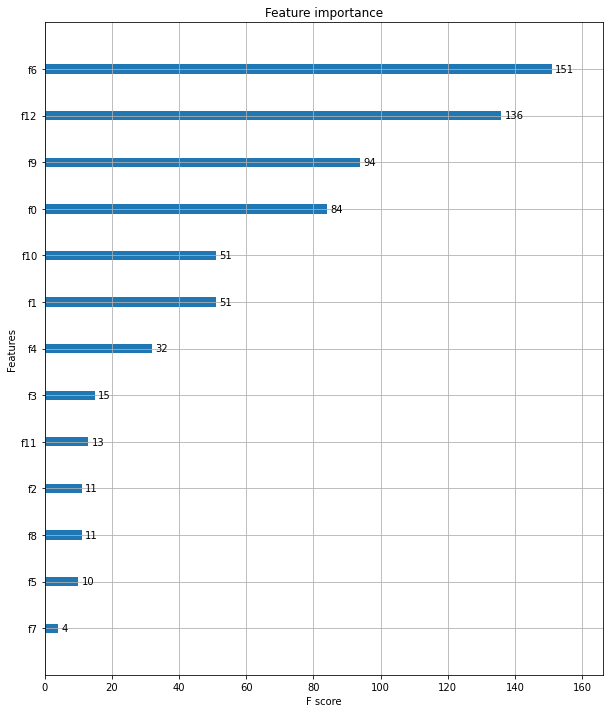

In [11]:
import matplotlib.pyplot as plt
import xgboost as xgb

fig, ax = plt.subplots(figsize=(10, 12))
xgb.plot_importance(xgb_model, ax=ax)

### 7.4. Visualization: Learned Tree

* [How to Visualize Gradient Boosting Decision Trees With XGBoost in Python](https://machinelearningmastery.com/visualize-gradient-boosting-decision-trees-xgboost-python/) > [Plot a Single XGBoost Decision Tree](https://machinelearningmastery.com/visualize-gradient-boosting-decision-trees-xgboost-python/), Machine Learning Mastery, 2020-08-27

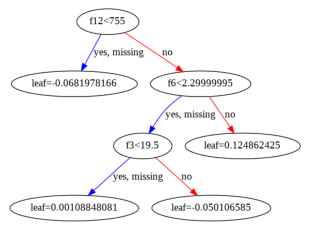

In [12]:
import graphviz

dot_data = xgb.to_graphviz(xgb_model)
xgb.plot_tree(xgb_model, num_trees=3)
plt.show()

If the orientation of the tree is changed from left to right,

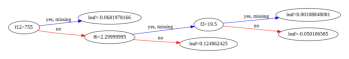

In [13]:
xgb.plot_tree(xgb_model, num_trees=3, rankdir='LR')
plt.show()

A clear version is below.

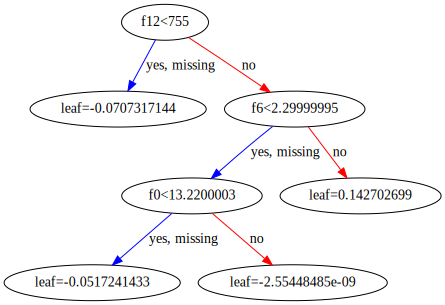

In [14]:
#import graphviz

dot_data = xgb.to_graphviz(xgb_model)
graph = graphviz.Source(dot_data)
graph

### 7.5. Cross-validation
* [sklearn.model_selection.cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)
  
> Evaluate metric(s) by cross-validation and also record fit/score times.

In [15]:
from sklearn.model_selection import cross_validate

cross_validation = cross_validate(
    estimator=xgb_model,
    X=dataset.data,
    y=dataset.target,
    cv=cv
)
print('Average fit time: {} (+/- {})'.format(cross_validation['fit_time'].mean(), cross_validation['fit_time'].std()))
print('Average score time: {} (+/- {})'.format(cross_validation['score_time'].mean(), cross_validation['score_time'].std()))
print('Average test score: {} (+/- {})'.format(cross_validation['test_score'].mean(), cross_validation['test_score'].std()))

Average fit time: 0.09645280838012696 (+/- 0.002678334190647265)
Average score time: 0.0009310722351074218 (+/- 2.45797414137584e-05)
Average test score: 0.9609523809523809 (+/- 0.028267341226138717)
